# Clinical Early Warning System — Sepsis Prediction
## Complete Pipeline: Data Preprocessing → Gen1 DNN → Gen2 LSTM/GRU → Gen3 ClinicalBERT
### Dataset: PhysioNet Sepsis Prediction Challenge 2019
---
**Objective:** Predict sepsis onset 6 hours early using ICU patient vital signs and clinical notes.

**Why Early Prediction Matters:** Sepsis kills 1 in 5 ICU patients. Every hour of delayed treatment increases mortality by 7%. An AI system that catches sepsis early can save lives.

**Key Metric: RECALL** — In healthcare, missing a sick patient (false negative) is far more dangerous than a false alarm (false positive). We optimize for Recall above all other metrics.

---
# PART 0 — DATASET OVERVIEW & EXPLORATION

In [6]:
# ── Import all libraries needed for the entire notebook ──────
# We import everything at the start to avoid repeated imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = 'true'

# Scikit-learn — preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from scipy.stats import pointbiserialr

# TensorFlow/Keras — DNN, LSTM, GRU
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      LSTM, GRU, Bidirectional)
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

# PyTorch + HuggingFace — ClinicalBERT
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForSequenceClassification,
                           get_linear_schedule_with_warmup)

print(f'TensorFlow : {tf.__version__}')
print(f'PyTorch    : {torch.__version__}')
print(f'Device     : {"GPU" if torch.cuda.is_available() else "CPU"}')
print('All libraries loaded ✅')

TensorFlow : 2.21.0
PyTorch    : 2.2.0+cpu
Device     : CPU
All libraries loaded ✅


In [7]:
# ── Load raw dataset ─────────────────────────────────────────
# Dataset.csv contains both training_setA and training_setB combined
# from the PhysioNet Sepsis Challenge 2019
# Each row = one patient's hourly ICU reading
# Each file has 41 columns: vitals + labs + demographics + SepsisLabel
df_raw = pd.read_csv('Dataset.csv')
df_raw.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

print(f'Total Rows    : {df_raw.shape[0]:,}')
print(f'Total Columns : {df_raw.shape[1]}')
print(f'\nColumn names:')
print(list(df_raw.columns))
print(f'\nFirst 3 rows:')
print(df_raw.head(3).to_string())

Total Rows    : 1,552,210
Total Columns : 43

Column names:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

First 3 rows:
   Hour    HR  O2Sat  Temp  SBP   MAP  DBP  Resp  EtCO2  BaseExcess  HCO3  FiO2  pH  PaCO2  SaO2  AST  BUN  Alkalinephos  Calcium  Chloride  Creatinine  Bilirubin_direct  Glucose  Lactate  Magnesium  Phosphate  Potassium  Bilirubin_total  TroponinI  Hct  Hgb  PTT  WBC  Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  SepsisLabel  Patient_ID
0     0   NaN    NaN   NaN  NaN   NaN  NaN   NaN    NaN         NaN   NaN   NaN NaN    NaN   NaN  NaN  NaN     

Non-Sepsis (0): 1,524,294  (98.20%)
Sepsis     (1): 27,916  (1.80%)

>> IMBALANCED — only 1.8% sepsis
>> This is why Recall matters more than Accuracy
>> A model predicting all 0s gets 98% accuracy but catches 0 sepsis cases


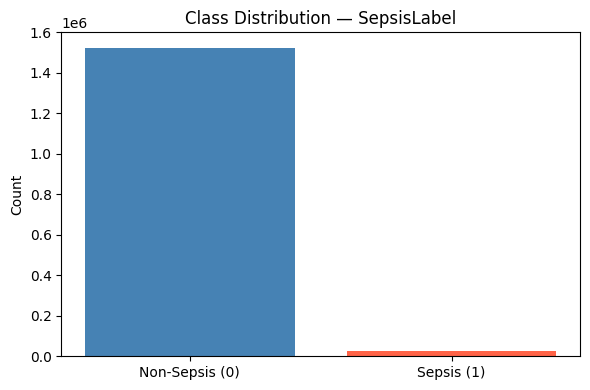

In [8]:
# ── Target column analysis ───────────────────────────────────
# SepsisLabel = 1 means sepsis onset detected (labeled 6 hours early)
# SepsisLabel = 0 means no sepsis at this hour
# Class imbalance is critical — only ~1.8% sepsis rows
counts = df_raw['SepsisLabel'].value_counts()
pcts   = df_raw['SepsisLabel'].value_counts(normalize=True) * 100
print(f'Non-Sepsis (0): {counts[0]:,}  ({pcts[0]:.2f}%)')
print(f'Sepsis     (1): {counts[1]:,}  ({pcts[1]:.2f}%)')
print(f'\n>> IMBALANCED — only {pcts[1]:.1f}% sepsis')
print('>> This is why Recall matters more than Accuracy')
print('>> A model predicting all 0s gets 98% accuracy but catches 0 sepsis cases')

# Plot class distribution
plt.figure(figsize=(6, 4))
plt.bar(['Non-Sepsis (0)', 'Sepsis (1)'], [counts[0], counts[1]],
        color=['steelblue', 'tomato'])
plt.title('Class Distribution — SepsisLabel')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150)
plt.show()

---
# PART 1 — FEATURE SELECTION & DATASET PREPARATION
### Why we select specific columns:
We use 3 methods to justify every column kept or dropped:
1. **Missing Value % threshold** — columns >70% missing are unusable
2. **Random Forest Importance** — data-driven proof of predictive power
3. **Point-Biserial Correlation** — statistical proof of relationship with SepsisLabel
4. **Sepsis-3 Clinical Criteria** — medical literature justification

Columns dropped (>70% missing): 27
  EtCO2                     96.3% missing
  BaseExcess                94.6% missing
  HCO3                      95.8% missing
  FiO2                      91.7% missing
  pH                        93.1% missing
  PaCO2                     94.4% missing
  SaO2                      96.5% missing
  AST                       98.4% missing
  BUN                       93.1% missing
  Alkalinephos              98.4% missing
  Calcium                   94.1% missing
  Chloride                  95.5% missing
  Creatinine                93.9% missing
  Bilirubin_direct          99.8% missing
  Glucose                   82.9% missing
  Lactate                   97.3% missing
  Magnesium                 93.7% missing
  Phosphate                 96.0% missing
  Potassium                 90.7% missing
  Bilirubin_total           98.5% missing
  TroponinI                 99.0% missing
  Hct                       91.1% missing
  Hgb                       92.6% missing

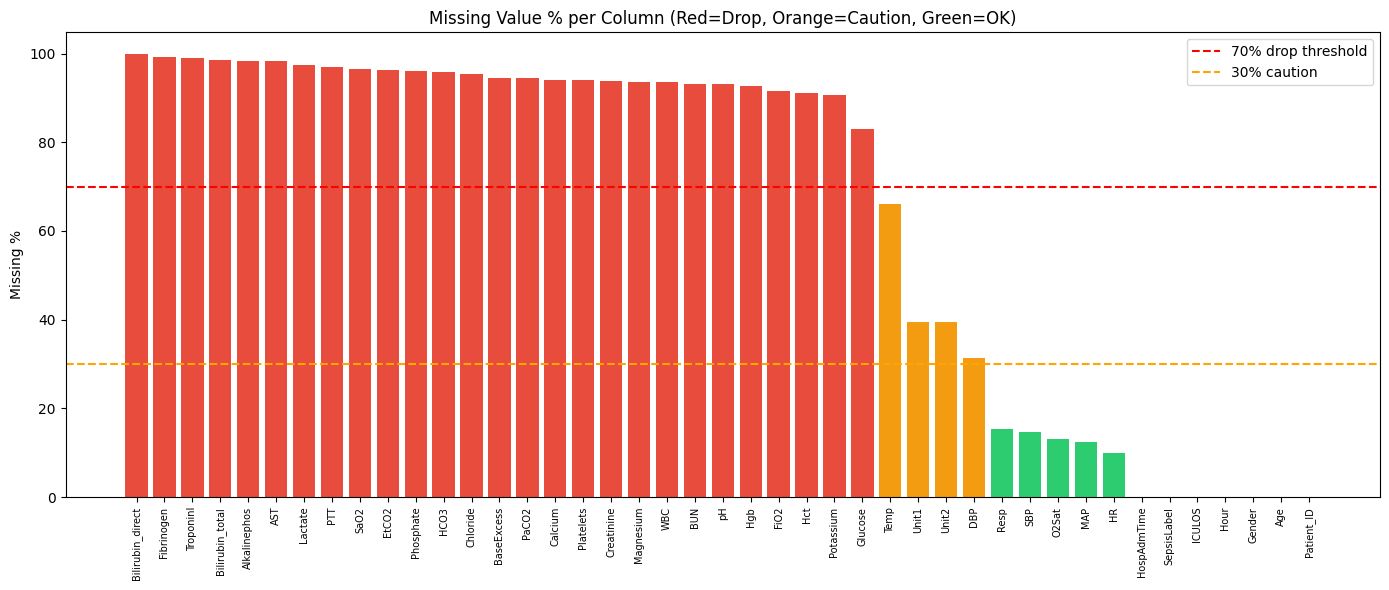


Shape after dropping: (1552210, 16)


In [9]:
# ── Step 1: Drop columns with >70% missing values ────────────
# Columns with >70% missing cannot be reliably imputed
# Even advanced imputation would introduce too much noise
# Safe columns are never dropped regardless of missing %
missing_pct = df_raw.isnull().mean() * 100
missing_pct_sorted = missing_pct.sort_values(ascending=False)

safe_cols = ['SepsisLabel', 'Patient_ID', 'Hour', 'ICULOS']
drop_high_missing = [c for c in missing_pct[missing_pct > 70].index
                     if c not in safe_cols]

print(f'Columns dropped (>70% missing): {len(drop_high_missing)}')
for col in drop_high_missing:
    print(f'  {col:<25} {missing_pct[col]:.1f}% missing')

# Plot missing values
plt.figure(figsize=(14, 6))
colors = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#2ecc71'
          for v in missing_pct_sorted.values]
plt.bar(missing_pct_sorted.index, missing_pct_sorted.values, color=colors)
plt.axhline(y=70, color='red', linestyle='--', linewidth=1.5, label='70% drop threshold')
plt.axhline(y=30, color='orange', linestyle='--', linewidth=1.5, label='30% caution')
plt.xticks(rotation=90, fontsize=7)
plt.ylabel('Missing %')
plt.title('Missing Value % per Column (Red=Drop, Orange=Caution, Green=OK)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_missing_values.png', dpi=150)
plt.show()

df_clean = df_raw.drop(columns=drop_high_missing)
print(f'\nShape after dropping: {df_clean.shape}')

Training RF on 100,000 rows...

RF Feature Importance:
    Feature  Importance
     ICULOS    0.229952
HospAdmTime    0.116922
        Age    0.113773
         HR    0.098404
        SBP    0.082535
        MAP    0.078908
       Resp    0.074979
        DBP    0.066507
       Temp    0.053625
      O2Sat    0.049294
     Gender    0.015064
      Unit1    0.010185
      Unit2    0.009853


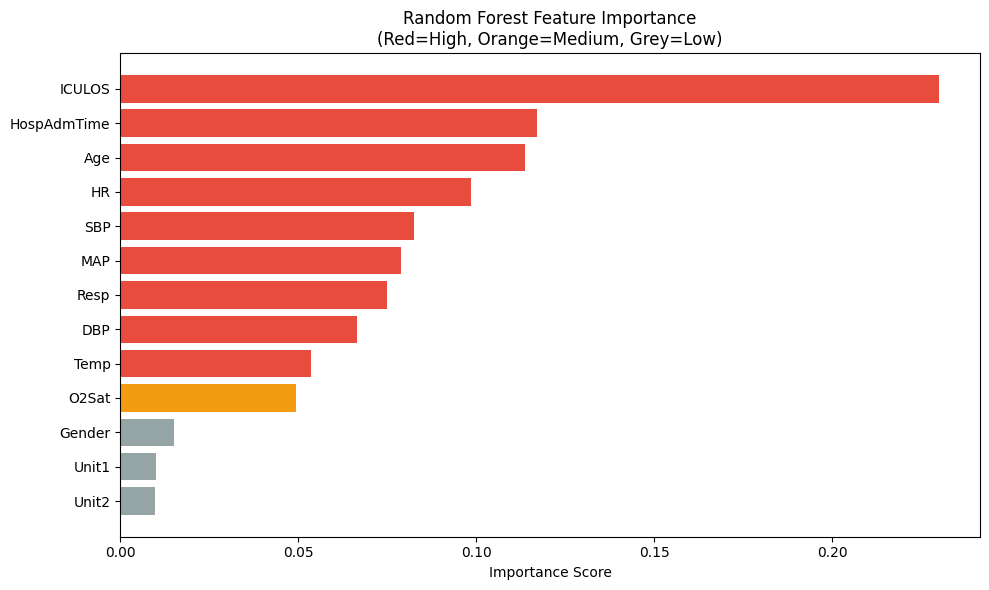

In [10]:
# ── Step 2: Random Forest Feature Importance ─────────────────
# RF importance tells us which features actually help predict sepsis
# We train RF on 100k sample rows (faster) with median imputation
# Features with near-zero importance are candidates for removal
feature_cols_rf = [c for c in df_clean.columns
                   if c not in ['SepsisLabel', 'Patient_ID', 'Hour', 'Unnamed: 0']]

df_rf = df_clean[feature_cols_rf + ['SepsisLabel']].dropna(subset=['SepsisLabel'])
df_rf_filled = df_rf.copy()
for col in feature_cols_rf:
    df_rf_filled[col] = df_rf_filled[col].fillna(df_rf_filled[col].median())

X_rf = df_rf_filled[feature_cols_rf]
y_rf = df_rf_filled['SepsisLabel']

# Sample 100k rows for speed
if len(X_rf) > 100000:
    idx = np.random.choice(len(X_rf), 100000, replace=False)
    X_rf = X_rf.iloc[idx]
    y_rf = y_rf.iloc[idx]

print(f'Training RF on {len(X_rf):,} rows...')
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             n_jobs=-1, class_weight='balanced')
rf.fit(X_rf, y_rf)

importance_df = pd.DataFrame({
    'Feature': feature_cols_rf,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nRF Feature Importance:')
print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0.05 else '#f39c12' if v > 0.02 else '#95a5a6'
          for v in importance_df['Importance']]
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance\n(Red=High, Orange=Medium, Grey=Low)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plot_rf_importance.png', dpi=150)
plt.show()

Correlation with SepsisLabel:
             correlation     pval
ICULOS            0.1338  0.00000
HR                0.0490  0.00000
Temp              0.0482  0.00000
Resp              0.0463  0.00000
Unit1             0.0254  0.00000
Unit2            -0.0254  0.00000
HospAdmTime      -0.0191  0.00000
MAP              -0.0188  0.00000
DBP              -0.0178  0.00000
SBP              -0.0134  0.00000
O2Sat            -0.0093  0.00000
Gender            0.0093  0.00000
Age               0.0002  0.81195


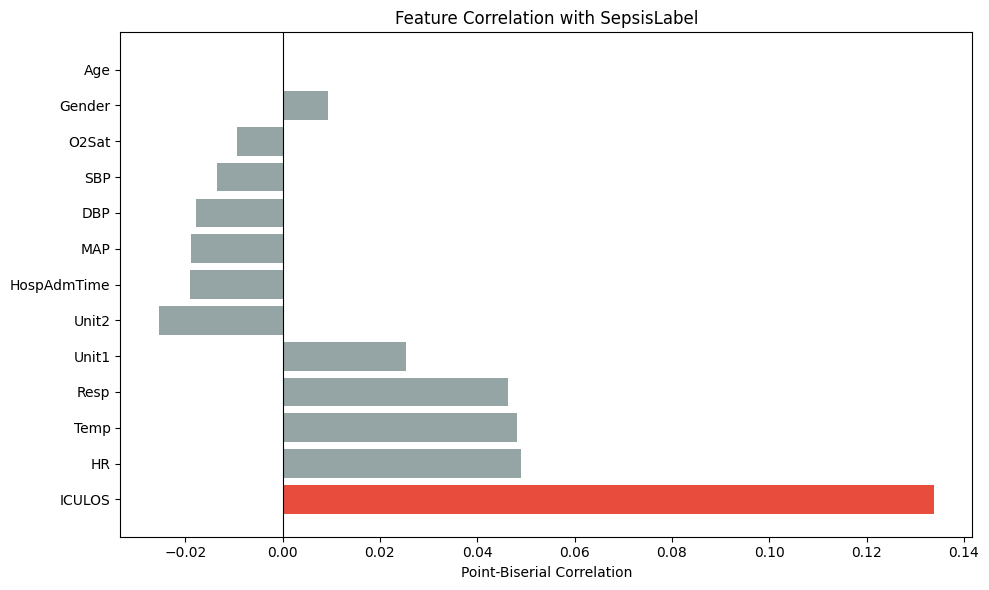

In [11]:
# ── Step 3: Point-Biserial Correlation with SepsisLabel ──────
# Measures linear relationship between each feature and sepsis outcome
# p-value < 0.05 means the correlation is statistically significant
correlations = {}
for col in feature_cols_rf:
    temp = df_clean[[col, 'SepsisLabel']].dropna()
    if len(temp) > 100:
        corr, pval = pointbiserialr(temp[col], temp['SepsisLabel'])
        correlations[col] = {'correlation': round(corr, 4), 'pval': round(pval, 6)}

corr_df = pd.DataFrame(correlations).T
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)
print('Correlation with SepsisLabel:')
print(corr_df.to_string())

# Plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if abs(v) > 0.1 else '#f39c12' if abs(v) > 0.05 else '#95a5a6'
          for v in corr_df['correlation']]
plt.barh(corr_df.index, corr_df['correlation'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Point-Biserial Correlation')
plt.title('Feature Correlation with SepsisLabel')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150)
plt.show()

In [12]:
# ── Step 4: Final Column Selection & Save Dataset_final.csv ──
# Based on RF importance + correlation + Sepsis-3 clinical criteria
# DROP: Gender (RF=0.014, Corr=0.009) — low on both metrics
# DROP: Unit1, Unit2 (RF=0.010) — administrative info, not clinical
# KEEP: All vital signs — HR, Resp, Temp, SBP, MAP, DBP, O2Sat
# KEEP: ICULOS, HospAdmTime, Age — high RF importance
# KEEP: Hour — time context for sequences
# KEEP: Patient_ID — needed for LSTM sequence grouping

final_columns = ['Patient_ID', 'Hour', 'ICULOS', 'HR', 'Resp', 'Temp',
                 'SBP', 'MAP', 'DBP', 'Age', 'HospAdmTime', 'O2Sat', 'SepsisLabel']

df_final = df_raw[final_columns].copy()

# Fill missing values with median BEFORE saving
# Median is used because vital signs have outliers that skew the mean
fill_cols = ['HR', 'Resp', 'Temp', 'SBP', 'MAP', 'DBP',
             'O2Sat', 'Age', 'HospAdmTime', 'ICULOS', 'Hour']

print('Filling missing values with MEDIAN:')
for col in fill_cols:
    median_val = df_final[col].median()
    before = df_final[col].isnull().sum()
    df_final[col] = df_final[col].fillna(median_val)
    print(f'  {col:<15} median={median_val:.2f}  filled {before:,} values')

df_final = df_final.dropna(subset=['SepsisLabel'])

print(f'\nFinal dataset shape : {df_final.shape}')
print(f'Total missing values: {df_final.isnull().sum().sum()}')
print(f'Columns: {list(df_final.columns)}')

df_final.to_csv('Dataset_final.csv', index=False)
print('\n✅ Saved: Dataset_final.csv')

Filling missing values with MEDIAN:
  HR              median=83.50  filled 153,399 values
  Resp            median=18.00  filled 238,335 values
  Temp            median=37.00  filled 1,026,984 values
  SBP             median=121.00  filled 226,265 values
  MAP             median=80.00  filled 193,270 values
  DBP             median=62.00  filled 486,554 values
  O2Sat           median=98.00  filled 202,736 values
  Age             median=64.00  filled 0 values
  HospAdmTime     median=-6.03  filled 8 values
  ICULOS          median=21.00  filled 0 values
  Hour            median=19.00  filled 0 values

Final dataset shape : (1552210, 13)
Total missing values: 0
Columns: ['Patient_ID', 'Hour', 'ICULOS', 'HR', 'Resp', 'Temp', 'SBP', 'MAP', 'DBP', 'Age', 'HospAdmTime', 'O2Sat', 'SepsisLabel']

✅ Saved: Dataset_final.csv


---
# PART 2 — GENERATION 1: DEEP NEURAL NETWORK (DNN)
### What is a DNN?
A Deep Neural Network learns patterns from flat tabular data — each row treated independently.
It does NOT consider the time order of readings. We compare two optimizers:
- **SGD**: Stochastic Gradient Descent — simple, slower convergence, sometimes better generalization
- **Adam**: Adaptive Moment Estimation — faster convergence, handles sparse gradients well

In [13]:
# ── Load dataset and prepare features for DNN ────────────────
# Patient_ID is dropped — it is just an identifier, not a clinical feature
# Including Patient_ID would cause data leakage (model memorizes IDs)
df = pd.read_csv('Dataset_final.csv')

feature_cols = ['Hour', 'ICULOS', 'HR', 'Resp', 'Temp',
                'SBP', 'MAP', 'DBP', 'Age', 'HospAdmTime', 'O2Sat']
target_col = 'SepsisLabel'

X = df[feature_cols].values
y = df[target_col].values

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {int(u)}: {c:,} ({c/len(y)*100:.2f}%)')

Features shape : (1552210, 11)
Target shape   : (1552210,)
  Class 0: 1,524,294 (98.20%)
  Class 1: 27,916 (1.80%)


In [14]:
# ── Train/Val/Test Split + Normalization ─────────────────────
# 70/15/15 split — standard for deep learning
# Scaler fitted ONLY on train data — prevents data leakage to val/test
# StandardScaler: zero mean, unit variance — required for neural networks
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Class weights — sepsis class gets 27x more penalty
# This forces the model to focus on Recall over Accuracy
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}

print(f'Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Class weights: {class_weight_dict}')
print(f'Sepsis gets {class_weight_dict[1]:.1f}x more weight ✅')

Train: 1,086,547 | Val: 232,831 | Test: 232,832
Class weights: {0: 0.5091569307014207, 1: 27.80172457909012}
Sepsis gets 27.8x more weight ✅


In [15]:
# ── DNN Architecture ─────────────────────────────────────────
# Dense(128) → BatchNorm → Dropout(0.3)
# Dense(64)  → BatchNorm → Dropout(0.3)
# Dense(32)  → BatchNorm → Dropout(0.2)
# Dense(1, sigmoid) — binary output
# BatchNormalization: normalizes layer outputs — faster training, stable gradients
# Dropout: randomly disables neurons — prevents overfitting
# Sigmoid: outputs probability 0-1 for binary classification
def build_dnn(optimizer):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(), Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_dnn(Adam()).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,353 (48.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
# ── Train Model 1: DNN + SGD ──────────────────────────────────
# SGD with momentum=0.9: classic optimizer, slower but stable
# EarlyStopping: stops when val_loss stops improving (patience=5)
# This prevents overfitting and saves training time
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_sgd = build_dnn(SGD(learning_rate=0.01, momentum=0.9))

start = time.time()
history_sgd = model_sgd.fit(
    X_train, y_train, epochs=50, batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=1)
sgd_time = time.time() - start
print(f'SGD Training time: {sgd_time:.1f} seconds')

Epoch 1/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7383 - loss: 0.6090 - val_accuracy: 0.7835 - val_loss: 0.5558
Epoch 2/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7601 - loss: 0.5936 - val_accuracy: 0.7855 - val_loss: 0.5491
Epoch 3/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7664 - loss: 0.5891 - val_accuracy: 0.8177 - val_loss: 0.5398
Epoch 4/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7680 - loss: 0.5862 - val_accuracy: 0.7540 - val_loss: 0.5841
Epoch 5/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7696 - loss: 0.5838 - val_accuracy: 0.7651 - val_loss: 0.5735
Epoch 6/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7687 - loss: 0.5831 - val_accuracy: 0.7970 - val_loss: 0.5544
Epoch 7/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7686 - loss: 0.5815 - val_accuracy: 0.7961 - val_loss: 0.5471
Epoch 8/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7701 - loss: 0.5815 - 

In [17]:
# ── Train Model 2: DNN + Adam ─────────────────────────────────
# Adam: adaptive learning rates per parameter — faster convergence
# learning_rate=0.001 is the standard default for Adam
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_adam = build_dnn(Adam(learning_rate=0.001))

start = time.time()
history_adam = model_adam.fit(
    X_train, y_train, epochs=50, batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=1)
adam_time = time.time() - start
print(f'Adam Training time: {adam_time:.1f} seconds')

Epoch 1/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7431 - loss: 0.6126 - val_accuracy: 0.7915 - val_loss: 0.5562
Epoch 2/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7663 - loss: 0.5888 - val_accuracy: 0.7726 - val_loss: 0.5576
Epoch 3/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7683 - loss: 0.5847 - val_accuracy: 0.7736 - val_loss: 0.5569
Epoch 4/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7674 - loss: 0.5803 - val_accuracy: 0.7891 - val_loss: 0.5522
Epoch 5/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7620 - loss: 0.5782 - val_accuracy: 0.7871 - val_loss: 0.5446
Epoch 6/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7623 - loss: 0.5766 - val_accuracy: 0.7661 - val_loss: 0.5646
Epoch 7/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7627 - loss: 0.5764 - val_accuracy: 0.7816 - val_loss: 0.5382
Epoch 8/50
4245/4245 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7604 - loss: 0.5738 - 

In [18]:
# ── Evaluate Gen 1 Models ─────────────────────────────────────
# Recall is the key metric: out of all real sepsis cases, how many did we catch?
# Low precision is acceptable — false alarms are less dangerous than missed cases
def evaluate_model_dnn(model, X_test, y_test, model_name):
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f'\n{model_name}:')
    print(f'  Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Sepsis', 'Sepsis']))
    return {'Model': model_name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'y_pred': y_pred}

res_sgd  = evaluate_model_dnn(model_sgd,  X_test, y_test, 'DNN + SGD')
res_adam = evaluate_model_dnn(model_adam, X_test, y_test, 'DNN + Adam')


DNN + SGD:
  Accuracy=0.8169 | Precision=0.0553 | Recall=0.5712 | F1=0.1009
              precision    recall  f1-score   support

   No Sepsis       0.99      0.82      0.90    228644
      Sepsis       0.06      0.57      0.10      4188

    accuracy                           0.82    232832
   macro avg       0.52      0.70      0.50    232832
weighted avg       0.97      0.82      0.88    232832


DNN + Adam:
  Accuracy=0.7816 | Precision=0.0509 | Recall=0.6311 | F1=0.0942
              precision    recall  f1-score   support

   No Sepsis       0.99      0.78      0.88    228644
      Sepsis       0.05      0.63      0.09      4188

    accuracy                           0.78    232832
   macro avg       0.52      0.71      0.48    232832
weighted avg       0.97      0.78      0.86    232832



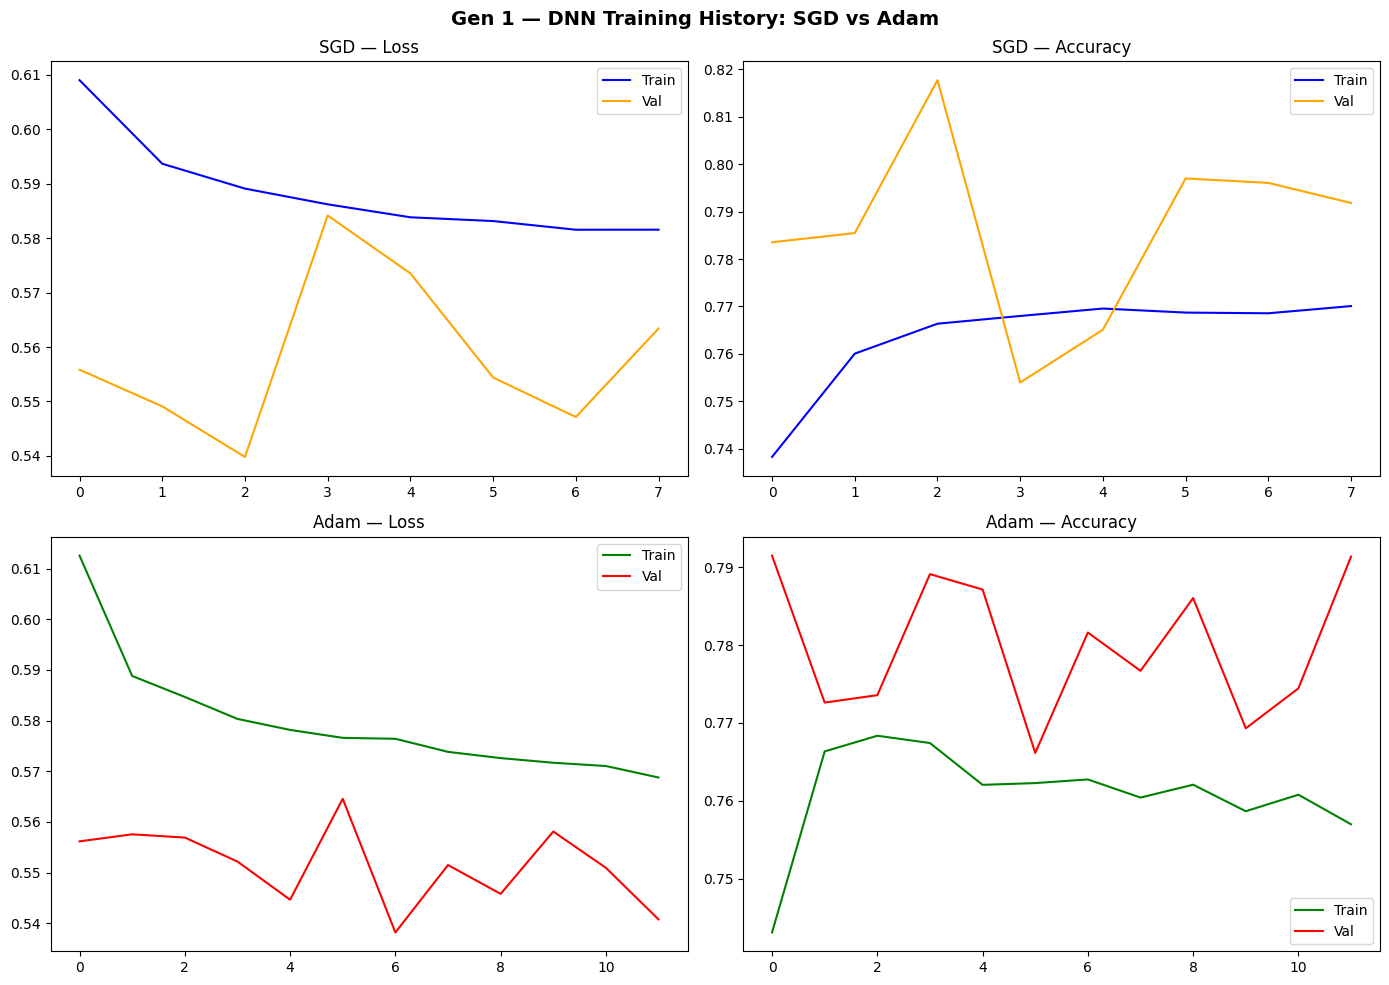

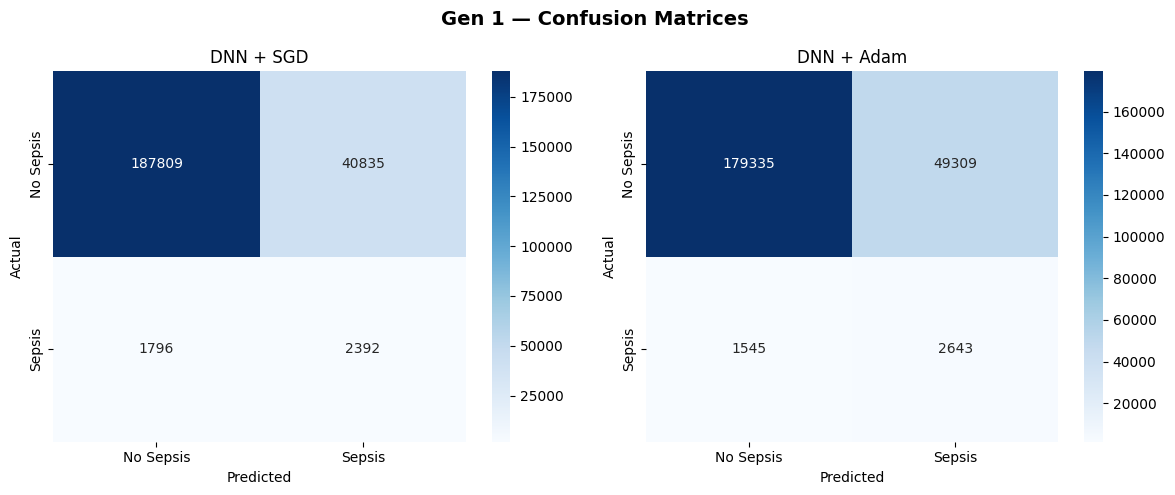

Gen 1 Results:
     Model  Accuracy  Precision  Recall     F1  Train Time (s)
 DNN + SGD    0.8169     0.0553  0.5712 0.1009            59.2
DNN + Adam    0.7816     0.0509  0.6311 0.0942           314.9


In [19]:
# ── Gen 1 Training History Plot ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gen 1 — DNN Training History: SGD vs Adam', fontsize=14, fontweight='bold')
for row, (hist, name, c1, c2) in enumerate([
    (history_sgd, 'SGD', 'blue', 'orange'),
    (history_adam, 'Adam', 'green', 'red')
]):
    axes[row,0].plot(hist.history['loss'], color=c1, label='Train')
    axes[row,0].plot(hist.history['val_loss'], color=c2, label='Val')
    axes[row,0].set_title(f'{name} — Loss')
    axes[row,0].legend()
    axes[row,1].plot(hist.history['accuracy'], color=c1, label='Train')
    axes[row,1].plot(hist.history['val_accuracy'], color=c2, label='Val')
    axes[row,1].set_title(f'{name} — Accuracy')
    axes[row,1].legend()
plt.tight_layout()
plt.savefig('gen1_training_history.png', dpi=150)
plt.show()

# ── Gen 1 Confusion Matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gen 1 — Confusion Matrices', fontsize=14, fontweight='bold')
for ax, res, title in zip(axes, [res_sgd, res_adam], ['DNN + SGD', 'DNN + Adam']):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Sepsis','Sepsis'], yticklabels=['No Sepsis','Sepsis'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('gen1_confusion_matrices.png', dpi=150)
plt.show()

# ── Gen 1 Comparison Table ────────────────────────────────────
gen1_comparison = pd.DataFrame([
    {'Model': 'DNN + SGD',  'Accuracy': res_sgd['Accuracy'],  'Precision': res_sgd['Precision'],
     'Recall': res_sgd['Recall'],  'F1': res_sgd['F1'],  'Train Time (s)': round(sgd_time,1)},
    {'Model': 'DNN + Adam', 'Accuracy': res_adam['Accuracy'], 'Precision': res_adam['Precision'],
     'Recall': res_adam['Recall'], 'F1': res_adam['F1'], 'Train Time (s)': round(adam_time,1)}
])
print('Gen 1 Results:')
print(gen1_comparison.to_string(index=False))
gen1_comparison.to_csv('gen1_results.csv', index=False)

---
# PART 3 — GENERATION 2: TIME SERIES MODELS (LSTM, Bi-LSTM, GRU)
### Why Time Series models?
DNN treats each row independently. But sepsis develops over hours — the TREND matters.
- HR going 80→90→105 over 3 hours is more alarming than a single reading of 105
- LSTM/GRU learn these temporal patterns by processing sequences

### LSTM vs GRU vs Bidirectional LSTM:
- **LSTM**: 4 gates — can learn long-range patterns, more parameters
- **GRU**: 2 gates — simpler, faster, similar performance
- **Bi-LSTM**: reads forward AND backward — better offline, NOT for live monitoring

In [20]:
# ── Build Patient Sequences for Time Series Models ────────────
# Group rows by Patient_ID — each patient has hourly readings
# Take last 24 hours per patient as one sequence
# Patients with < 24 hours get zero-padded at the beginning
# Label = max(SepsisLabel) — 1 if patient developed sepsis at any point
SEQUENCE_LENGTH = 24
seq_feature_cols = ['Hour', 'ICULOS', 'HR', 'Resp', 'Temp',
                    'SBP', 'MAP', 'DBP', 'Age', 'HospAdmTime', 'O2Sat']

df2 = pd.read_csv('Dataset_final.csv')
df2 = df2.sort_values(['Patient_ID', 'Hour']).reset_index(drop=True)

print(f'Total unique patients: {df2["Patient_ID"].nunique():,}')

# Sample 30,000 patients — full 120k would require ~10GB RAM
np.random.seed(42)
all_pids = df2['Patient_ID'].unique()
sampled_pids = np.random.choice(all_pids, size=min(30000, len(all_pids)), replace=False)

sequences, seq_labels = [], []
for pid in sampled_pids:
    pdata = df2[df2['Patient_ID'] == pid][seq_feature_cols + ['SepsisLabel']]
    feats = pdata[seq_feature_cols].values
    label = pdata['SepsisLabel'].max()
    if len(feats) >= SEQUENCE_LENGTH:
        seq = feats[-SEQUENCE_LENGTH:]
    else:
        pad = np.zeros((SEQUENCE_LENGTH - len(feats), len(seq_feature_cols)))
        seq = np.vstack([pad, feats])
    sequences.append(seq)
    seq_labels.append(label)

X_seq = np.array(sequences)
y_seq = np.array(seq_labels)
print(f'Sequence shape: {X_seq.shape}')
unique2, counts2 = np.unique(y_seq, return_counts=True)
for u, c in zip(unique2, counts2):
    print(f'  Class {int(u)}: {c:,} ({c/len(y_seq)*100:.2f}%)')

Total unique patients: 40,336
Sequence shape: (30000, 24, 11)
  Class 0: 27,812 (92.71%)
  Class 1: 2,188 (7.29%)


In [21]:
# ── Normalize + Split sequences ───────────────────────────────
# Reshape to 2D for StandardScaler, then back to 3D
# Scaler fitted on train only — prevents data leakage
n_samples, n_steps, n_feats = X_seq.shape
scaler2 = StandardScaler()
X_seq_scaled = scaler2.fit_transform(X_seq.reshape(-1, n_feats)).reshape(n_samples, n_steps, n_feats)

X_tr2, X_tmp2, y_tr2, y_tmp2 = train_test_split(
    X_seq_scaled, y_seq, test_size=0.30, random_state=42, stratify=y_seq)
X_v2, X_te2, y_v2, y_te2 = train_test_split(
    X_tmp2, y_tmp2, test_size=0.50, random_state=42, stratify=y_tmp2)

cw2 = compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
cw2_dict = {0: cw2[0], 1: cw2[1]}

print(f'Train: {X_tr2.shape} | Val: {X_v2.shape} | Test: {X_te2.shape}')
print(f'Class weights: {cw2_dict}')

Train: (21000, 24, 11) | Val: (4500, 24, 11) | Test: (4500, 24, 11)
Class weights: {0: 0.5393466200945141, 1: 6.85378590078329}


In [22]:
# ── Evaluate helper for sequence models ──────────────────────
def evaluate_seq_model(model, X_te, y_te, name):
    y_pred = (model.predict(X_te, verbose=0) > 0.5).astype(int).flatten()
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    print(f'\n{name}: Acc={acc:.4f} | Prec={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}')
    print(classification_report(y_te, y_pred, target_names=['No Sepsis','Sepsis']))
    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'y_pred': y_pred}

es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ── Model 3: LSTM ─────────────────────────────────────────────
# Two stacked LSTM layers: first returns sequences, second returns single vector
# Dropout prevents overfitting between LSTM layers
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, len(seq_feature_cols))),
    Dropout(0.3),
    LSTM(32), Dropout(0.3),
    Dense(16, activation='relu'), Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()
history_lstm = model_lstm.fit(X_tr2, y_tr2, epochs=30, batch_size=256,
    validation_data=(X_v2, y_v2), class_weight=cw2_dict, callbacks=[es2], verbose=1)
lstm_time = time.time() - start
print(f'LSTM time: {lstm_time:.1f}s')

Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.8179 - loss: 0.5292 - val_accuracy: 0.8224 - val_loss: 0.4739
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.8692 - loss: 0.4670 - val_accuracy: 0.8638 - val_loss: 0.4472
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.8768 - loss: 0.4566 - val_accuracy: 0.8820 - val_loss: 0.4151
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8545 - loss: 0.4652 - val_accuracy: 0.8980 - val_loss: 0.3673
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.8767 - loss: 0.4469 - val_accuracy: 0.8720 - val_loss: 0.4272
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.8779 - loss: 0.4431 - val_accuracy: 0.8582 - val_loss: 0.4159
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.8640 - loss: 0.4403 - val_accuracy: 0.8878 - val_loss: 0.3999
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.8777 - loss: 0.4331 - val_accuracy: 0.8

In [23]:
# ── Model 4: Bidirectional LSTM ───────────────────────────────
# Reads sequence both forward and backward — doubles parameters
# Better accuracy but NOT suitable for live monitoring
# because it needs future data to read backwards
es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(SEQUENCE_LENGTH, len(seq_feature_cols))),
    Dropout(0.3),
    Bidirectional(LSTM(32)), Dropout(0.3),
    Dense(16, activation='relu'), Dense(1, activation='sigmoid')
])
model_bilstm.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()
history_bilstm = model_bilstm.fit(X_tr2, y_tr2, epochs=30, batch_size=256,
    validation_data=(X_v2, y_v2), class_weight=cw2_dict, callbacks=[es2], verbose=1)
bilstm_time = time.time() - start
print(f'Bi-LSTM time: {bilstm_time:.1f}s')

Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.8233 - loss: 0.5109 - val_accuracy: 0.8827 - val_loss: 0.4434
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.8753 - loss: 0.4603 - val_accuracy: 0.8976 - val_loss: 0.3770
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - accuracy: 0.8704 - loss: 0.4538 - val_accuracy: 0.8413 - val_loss: 0.4261
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 155ms/step - accuracy: 0.8742 - loss: 0.4441 - val_accuracy: 0.8458 - val_loss: 0.4415
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 0.8661 - loss: 0.4390 - val_accuracy: 0.8673 - val_loss: 0.3969
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 151ms/step - accuracy: 0.8754 - loss: 0.4316 - val_accuracy: 0.8689 - val_loss: 0.4189
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.8682 - loss: 0.4301 - val_accuracy: 0.8753 - val_loss: 0.3753
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.8702 - loss: 0.4263 - val_accu

In [24]:
# ── Model 5: GRU ──────────────────────────────────────────────
# GRU has 2 gates (reset + update) vs LSTM 4 gates
# Fewer parameters = faster training, similar performance
# Often preferred for medical time series (faster inference in hospital systems)
es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, len(seq_feature_cols))),
    Dropout(0.3),
    GRU(32), Dropout(0.3),
    Dense(16, activation='relu'), Dense(1, activation='sigmoid')
])
model_gru.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()
history_gru = model_gru.fit(X_tr2, y_tr2, epochs=30, batch_size=256,
    validation_data=(X_v2, y_v2), class_weight=cw2_dict, callbacks=[es2], verbose=1)
gru_time = time.time() - start
print(f'GRU time: {gru_time:.1f}s')

Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7499 - loss: 0.5677 - val_accuracy: 0.7220 - val_loss: 0.6300
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8493 - loss: 0.4702 - val_accuracy: 0.8876 - val_loss: 0.3908
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8606 - loss: 0.4584 - val_accuracy: 0.8289 - val_loss: 0.4894
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8710 - loss: 0.4562 - val_accuracy: 0.8489 - val_loss: 0.4477
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8759 - loss: 0.4515 - val_accuracy: 0.8378 - val_loss: 0.4703
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8679 - loss: 0.4475 - val_accuracy: 0.8958 - val_loss: 0.3748
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8712 - loss: 0.4443 - val_accuracy: 0.8969 - val_loss: 0.3316
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8706 - loss: 0.4428 - val_accuracy: 0.8844 - v


LSTM: Acc=0.8973 | Prec=0.3820 | Recall=0.6616 | F1=0.4844
              precision    recall  f1-score   support

   No Sepsis       0.97      0.92      0.94      4172
      Sepsis       0.38      0.66      0.48       328

    accuracy                           0.90      4500
   macro avg       0.68      0.79      0.71      4500
weighted avg       0.93      0.90      0.91      4500


Bidirectional LSTM: Acc=0.8858 | Prec=0.3595 | Recall=0.7256 | F1=0.4808
              precision    recall  f1-score   support

   No Sepsis       0.98      0.90      0.94      4172
      Sepsis       0.36      0.73      0.48       328

    accuracy                           0.89      4500
   macro avg       0.67      0.81      0.71      4500
weighted avg       0.93      0.89      0.90      4500


GRU: Acc=0.8989 | Prec=0.3896 | Recall=0.6829 | F1=0.4961
              precision    recall  f1-score   support

   No Sepsis       0.97      0.92      0.94      4172
      Sepsis       0.39      0.68      0.50 

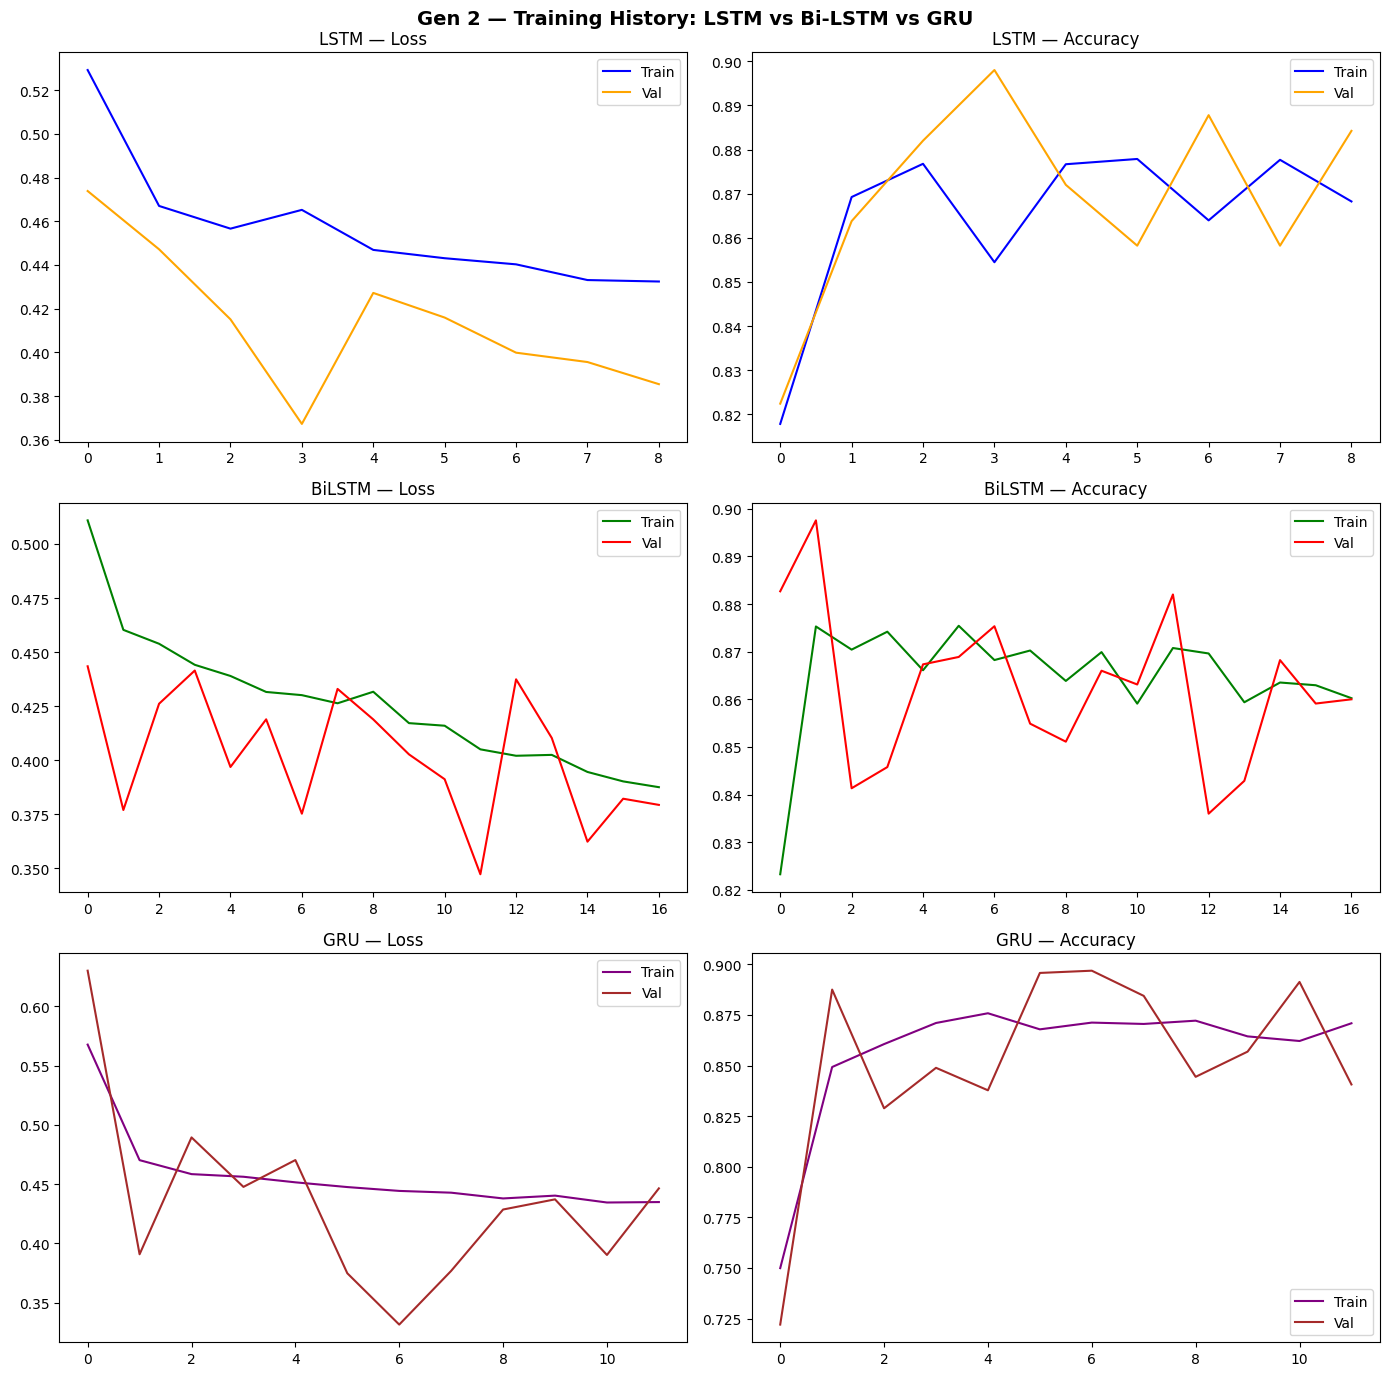

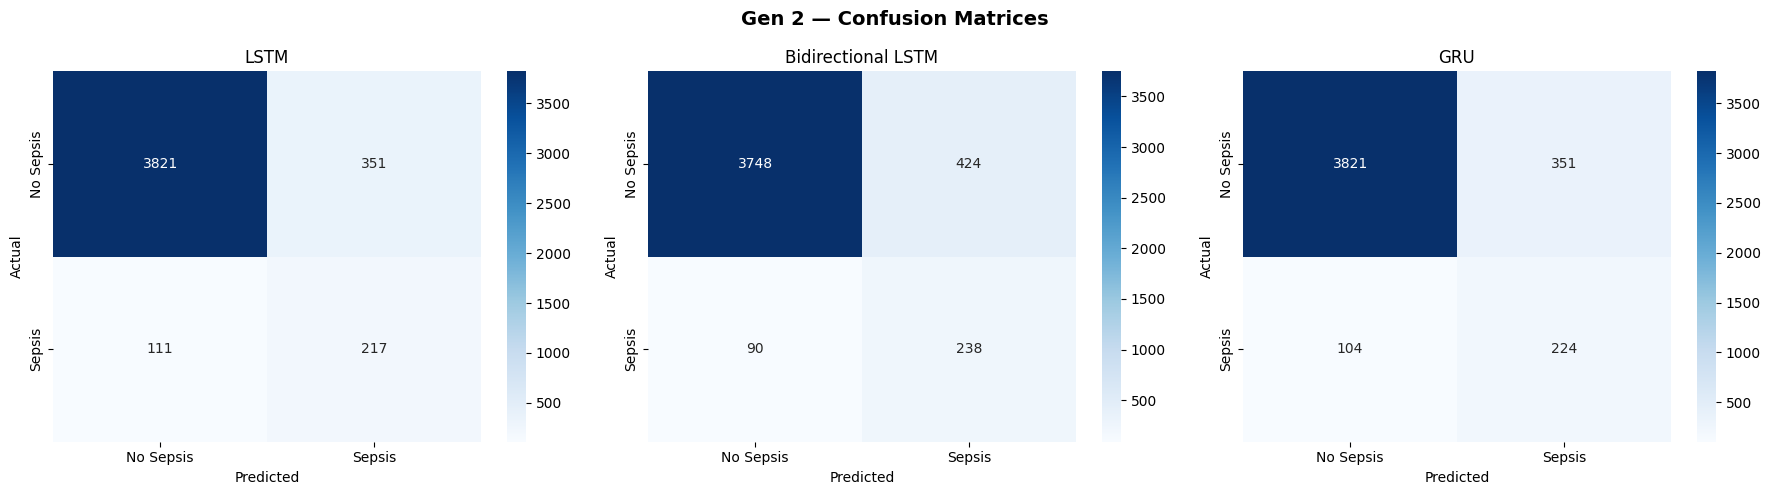

Gen 2 Results:
             Model  Accuracy  Precision  Recall     F1  Train Time (s)
              LSTM    0.8973     0.3820  0.6616 0.4844            86.4
Bidirectional LSTM    0.8858     0.3595  0.7256 0.4808           185.7
               GRU    0.8989     0.3896  0.6829 0.4961            21.9


In [25]:
# ── Evaluate all Gen 2 models ─────────────────────────────────
res_lstm   = evaluate_seq_model(model_lstm,   X_te2, y_te2, 'LSTM')
res_bilstm = evaluate_seq_model(model_bilstm, X_te2, y_te2, 'Bidirectional LSTM')
res_gru    = evaluate_seq_model(model_gru,    X_te2, y_te2, 'GRU')

# Training history plots
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Gen 2 — Training History: LSTM vs Bi-LSTM vs GRU', fontsize=14, fontweight='bold')
for i, (hist, name, c1, c2) in enumerate([
    (history_lstm,   'LSTM',   'blue',   'orange'),
    (history_bilstm, 'BiLSTM', 'green',  'red'),
    (history_gru,    'GRU',    'purple', 'brown')
]):
    axes[i,0].plot(hist.history['loss'], color=c1, label='Train')
    axes[i,0].plot(hist.history['val_loss'], color=c2, label='Val')
    axes[i,0].set_title(f'{name} — Loss'); axes[i,0].legend()
    axes[i,1].plot(hist.history['accuracy'], color=c1, label='Train')
    axes[i,1].plot(hist.history['val_accuracy'], color=c2, label='Val')
    axes[i,1].set_title(f'{name} — Accuracy'); axes[i,1].legend()
plt.tight_layout()
plt.savefig('gen2_training_history.png', dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gen 2 — Confusion Matrices', fontsize=14, fontweight='bold')
for ax, res, title in zip(axes, [res_lstm, res_bilstm, res_gru],
                           ['LSTM', 'Bidirectional LSTM', 'GRU']):
    cm = confusion_matrix(y_te2, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Sepsis','Sepsis'], yticklabels=['No Sepsis','Sepsis'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('gen2_confusion_matrices.png', dpi=150)
plt.show()

gen2_comparison = pd.DataFrame([
    {'Model': 'LSTM', 'Accuracy': res_lstm['Accuracy'], 'Precision': res_lstm['Precision'],
     'Recall': res_lstm['Recall'], 'F1': res_lstm['F1'], 'Train Time (s)': round(lstm_time,1)},
    {'Model': 'Bidirectional LSTM', 'Accuracy': res_bilstm['Accuracy'], 'Precision': res_bilstm['Precision'],
     'Recall': res_bilstm['Recall'], 'F1': res_bilstm['F1'], 'Train Time (s)': round(bilstm_time,1)},
    {'Model': 'GRU', 'Accuracy': res_gru['Accuracy'], 'Precision': res_gru['Precision'],
     'Recall': res_gru['Recall'], 'F1': res_gru['F1'], 'Train Time (s)': round(gru_time,1)}
])
print('Gen 2 Results:')
print(gen2_comparison.to_string(index=False))
gen2_comparison.to_csv('gen2_results.csv', index=False)

---
# PART 4 — GENERATION 3: ClinicalBERT (NLP)
### Why ClinicalBERT?
BERT (Bidirectional Encoder Representations from Transformers) understands language context.
Bio_ClinicalBERT is pre-trained on MIMIC-III real hospital notes — it already knows medical terms.

### No clinical text in our dataset?
PhysioNet has only vitals — no doctor notes. We generate **synthetic clinical notes** from vitals.
This is standard practice in medical NLP research.

### Frozen vs Full Fine-Tune:
- **Frozen**: Only the final classification layer trains (1,538 params). Fast but limited.
- **Full Fine-Tune**: All 108M parameters adapt to sepsis task. Slower but higher Recall.

In [31]:
# ── Generate Synthetic Clinical Notes from Vitals ─────────────
# Each patient's last reading is converted to a doctor-style note
# Rules based on Sepsis-3 clinical criteria thresholds
# NO SepsisLabel information included — prevents data leakage
def generate_clinical_note(row):
    parts = []
    hr = row['HR']
    if hr > 100: parts.append(f'Tachycardia noted, heart rate {hr:.0f} bpm.')
    elif hr < 60: parts.append(f'Bradycardia noted, heart rate {hr:.0f} bpm.')
    else: parts.append(f'Heart rate normal at {hr:.0f} bpm.')

    temp = row['Temp']
    if temp > 38.3: parts.append(f'Fever present, temperature {temp:.1f}C, infection suspected.')
    elif temp < 36.0: parts.append(f'Hypothermia noted, temperature {temp:.1f}C.')
    else: parts.append(f'Temperature normal at {temp:.1f}C.')

    resp = row['Resp']
    if resp > 20: parts.append(f'Tachypnea observed, respiratory rate {resp:.0f} breaths/min.')
    elif resp < 12: parts.append(f'Bradypnea noted, respiratory rate {resp:.0f} breaths/min.')
    else: parts.append(f'Respiratory rate stable at {resp:.0f} breaths/min.')

    sbp, dbp, map_val = row['SBP'], row['DBP'], row['MAP']
    if sbp < 90: parts.append(f'Hypotension detected, systolic BP {sbp:.0f} mmHg.')
    elif sbp > 140: parts.append(f'Hypertension noted, systolic BP {sbp:.0f} mmHg.')
    else: parts.append(f'BP {sbp:.0f}/{dbp:.0f} mmHg, MAP {map_val:.0f}.')

    o2 = row['O2Sat']
    if o2 < 95: parts.append(f'Low oxygen saturation {o2:.0f}%, supplemental oxygen required.')
    else: parts.append(f'Oxygen saturation acceptable at {o2:.0f}%.')

    parts.append(f'Patient age {row["Age"]:.0f}, ICU stay {row["ICULOS"]:.0f} hours.')
    return ' '.join(parts)

df3 = pd.read_csv('Dataset_final.csv')
df3_last = df3.sort_values(['Patient_ID','Hour']).groupby('Patient_ID').last().reset_index()
df3_sample = df3_last.sample(n=min(5000, len(df3_last)), random_state=42).reset_index(drop=True)
df3_sample['clinical_note'] = df3_sample.apply(generate_clinical_note, axis=1)

print(f'Sample notes generated: {len(df3_sample)}')
print(f'Class distribution:')
print(df3_sample['SepsisLabel'].value_counts())
print(f'\nSample sepsis note:')
print(df3_sample[df3_sample['SepsisLabel']==1].iloc[0]['clinical_note'])

# ── Display 5 random sample notes with vitals ─────────────────
print('\n' + '=' * 60)
print('5 RANDOM PATIENT NOTES SAMPLE')
print('=' * 60)

random_sample = df3_sample.sample(5, random_state=99)
for i, (_, row) in enumerate(random_sample.iterrows()):
    print(f'\n--- Patient {i+1} ---')
    print(f'Vitals: HR={row["HR"]:.0f}, Temp={row["Temp"]:.1f}, '
          f'Resp={row["Resp"]:.0f}, SBP={row["SBP"]:.0f}, '
          f'O2Sat={row["O2Sat"]:.0f}, Age={row["Age"]:.0f}, '
          f'ICULOS={row["ICULOS"]:.0f}')
    print(f'Label : {int(row["SepsisLabel"])} '
          f'({"SEPSIS" if row["SepsisLabel"]==1 else "NO SEPSIS"})')
    print(f'Note  : {row["clinical_note"]}')

# ── Save for verification ──────────────────────────────────────
print('\n' + '=' * 60)
print('Save df_sample to CSV for verification:')
print('=' * 60)
df3_sample.to_csv('df_sample_check.csv', index=False)
print(f'Saved: df_sample_check.csv')
print(f'Rows: {len(df3_sample)}, Columns: {len(df3_sample.columns)}')

Sample notes generated: 5000
Class distribution:
SepsisLabel
0    4675
1     325
Name: count, dtype: int64

Sample sepsis note:
Heart rate normal at 79 bpm. Temperature normal at 37.0C. Bradypnea noted, respiratory rate 9 breaths/min. BP 131/57 mmHg, MAP 81. Oxygen saturation acceptable at 100%. Patient age 72, ICU stay 52 hours.

5 RANDOM PATIENT NOTES SAMPLE

--- Patient 1 ---
Vitals: HR=80, Temp=37.3, Resp=18, SBP=119, O2Sat=90, Age=72, ICULOS=38
Label : 0 (NO SEPSIS)
Note  : Heart rate normal at 80 bpm. Temperature normal at 37.3C. Respiratory rate stable at 18 breaths/min. BP 119/54 mmHg, MAP 76. Low oxygen saturation 90%, supplemental oxygen required. Patient age 72, ICU stay 38 hours.

--- Patient 2 ---
Vitals: HR=94, Temp=37.7, Resp=18, SBP=125, O2Sat=95, Age=74, ICULOS=38
Label : 0 (NO SEPSIS)
Note  : Heart rate normal at 94 bpm. Temperature normal at 37.7C. Respiratory rate stable at 18 breaths/min. BP 125/44 mmHg, MAP 65. Oxygen saturation acceptable at 95%. Patient age 74, 

In [32]:
# ── Load ClinicalBERT Tokenizer ───────────────────────────────
# Bio_ClinicalBERT is pre-trained on MIMIC-III clinical notes
# It already understands medical terms like tachycardia, hypotension, sepsis
# This gives it a head start over general BERT trained on Wikipedia
MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Tokenizer loaded ✅ | Device: {device}')

Tokenizer loaded ✅ | Device: cpu


In [33]:
# ── PyTorch Dataset + DataLoaders ────────────────────────────
# BERT requires tokenized input with attention masks
# max_length=128 covers our synthetic notes (typically 60-80 tokens)
# batch_size=16 is standard for BERT fine-tuning to fit in GPU memory
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), truncation=True,
                             padding='max_length', max_length=self.max_len, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'label': torch.tensor(int(self.labels[idx]), dtype=torch.long)}

texts3  = df3_sample['clinical_note'].values
labels3 = df3_sample['SepsisLabel'].values.astype(int)

X_tr3, X_tmp3, y_tr3, y_tmp3 = train_test_split(texts3, labels3, test_size=0.30, random_state=42, stratify=labels3)
X_v3,  X_te3,  y_v3,  y_te3  = train_test_split(X_tmp3, y_tmp3, test_size=0.50, random_state=42, stratify=y_tmp3)

train_loader = DataLoader(ClinicalDataset(X_tr3, y_tr3, tokenizer), batch_size=16, shuffle=True)
val_loader   = DataLoader(ClinicalDataset(X_v3,  y_v3,  tokenizer), batch_size=16, shuffle=False)
test_loader  = DataLoader(ClinicalDataset(X_te3, y_te3, tokenizer), batch_size=16, shuffle=False)

print(f'Train: {len(X_tr3)} | Val: {len(X_v3)} | Test: {len(X_te3)}')

Train: 3500 | Val: 750 | Test: 750


In [34]:
# ── BERT Training + Evaluation Helpers ───────────────────────
def train_bert(model, train_loader, val_loader, epochs=3, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, total_steps//10, total_steps)
    n_neg = (y_tr3==0).sum(); n_pos = (y_tr3==1).sum()
    criterion = torch.nn.CrossEntropyLoss(
        weight=torch.tensor([1.0, n_neg/n_pos], dtype=torch.float).to(device))
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    for epoch in range(epochs):
        model.train()
        tl, tc, tt = 0, 0, 0
        for batch in train_loader:
            ids, mask, lbl = (batch['input_ids'].to(device),
                              batch['attention_mask'].to(device),
                              batch['label'].to(device))
            optimizer.zero_grad()
            out = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            tl += loss.item()
            tc += (out.logits.argmax(1)==lbl).sum().item(); tt += len(lbl)
        model.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                ids, mask, lbl = (batch['input_ids'].to(device),
                                  batch['attention_mask'].to(device),
                                  batch['label'].to(device))
                out = model(input_ids=ids, attention_mask=mask)
                vl += criterion(out.logits, lbl).item()
                vc += (out.logits.argmax(1)==lbl).sum().item(); vt += len(lbl)
        history['train_loss'].append(tl/len(train_loader))
        history['val_loss'].append(vl/len(val_loader))
        history['train_acc'].append(tc/tt)
        history['val_acc'].append(vc/vt)
        print(f'Epoch {epoch+1}/{epochs} | TrLoss={tl/len(train_loader):.4f} TrAcc={tc/tt:.4f} | ValLoss={vl/len(val_loader):.4f} ValAcc={vc/vt:.4f}')
    return model, history

def evaluate_bert(model, test_loader, name):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            ids, mask, lbl = (batch['input_ids'].to(device),
                              batch['attention_mask'].to(device),
                              batch['label'].to(device))
            out = model(input_ids=ids, attention_mask=mask)
            preds.extend(out.logits.argmax(1).cpu().numpy())
            trues.extend(lbl.cpu().numpy())
    acc  = accuracy_score(trues, preds)
    prec = precision_score(trues, preds, zero_division=0)
    rec  = recall_score(trues, preds, zero_division=0)
    f1   = f1_score(trues, preds, zero_division=0)
    print(f'\n{name}: Acc={acc:.4f} | Prec={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}')
    print(classification_report(trues, preds, target_names=['No Sepsis','Sepsis']))
    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'y_pred': preds, 'y_true': trues}

print('BERT helpers ready ✅')

BERT helpers ready ✅


In [35]:
# ── Model 6a: ClinicalBERT FROZEN ─────────────────────────────
# Freeze all BERT layers — only the 1,538-param classifier trains
# Fast training but limited — BERT knowledge not adapted to our task
# Useful as a baseline to compare against full fine-tuning
print('Loading ClinicalBERT — FROZEN')
model_frozen = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
for name, param in model_frozen.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_frozen.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

start = time.time()
model_frozen, hist_frozen = train_bert(model_frozen, train_loader, val_loader, epochs=3, lr=2e-4)
frozen_time = time.time() - start
print(f'Frozen training time: {frozen_time:.1f}s')

Loading ClinicalBERT — FROZEN


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable: 1,538 / 108,311,810 (0.00%)
Epoch 1/3 | TrLoss=0.6678 TrAcc=0.7937 | ValLoss=0.6366 ValAcc=0.9293
Epoch 2/3 | TrLoss=0.6759 TrAcc=0.6549 | ValLoss=0.6299 ValAcc=0.9253
Epoch 3/3 | TrLoss=0.6762 TrAcc=0.7314 | ValLoss=0.6235 ValAcc=0.8680
Frozen training time: 1325.7s


In [36]:
# ── Model 6b: ClinicalBERT FULL FINE-TUNE ─────────────────────
# All 108M parameters train — BERT fully adapts to sepsis detection
# Slower but expected to achieve higher Recall
# lr=2e-5 is the standard fine-tuning learning rate for BERT
print('Loading ClinicalBERT — FULL FINE-TUNE')
model_ft = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
for param in model_ft.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_ft.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

start = time.time()
model_ft, hist_ft = train_bert(model_ft, train_loader, val_loader, epochs=3, lr=2e-5)
ft_time = time.time() - start
print(f'Full fine-tune time: {ft_time:.1f}s')

Loading ClinicalBERT — FULL FINE-TUNE


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable: 108,311,810 / 108,311,810 (100.00%)
Epoch 1/3 | TrLoss=0.6323 TrAcc=0.8151 | ValLoss=0.5711 ValAcc=0.9600
Epoch 2/3 | TrLoss=0.6936 TrAcc=0.9543 | ValLoss=0.6240 ValAcc=0.9573
Epoch 3/3 | TrLoss=0.7421 TrAcc=0.9554 | ValLoss=0.5647 ValAcc=0.9587
Full fine-tune time: 6238.7s



ClinicalBERT Frozen: Acc=0.8600 | Prec=0.1481 | Recall=0.2500 | F1=0.1860
              precision    recall  f1-score   support

   No Sepsis       0.95      0.90      0.92       702
      Sepsis       0.15      0.25      0.19        48

    accuracy                           0.86       750
   macro avg       0.55      0.58      0.55       750
weighted avg       0.90      0.86      0.88       750


ClinicalBERT Full Fine-Tune: Acc=0.9507 | Prec=0.6486 | Recall=0.5000 | F1=0.5647
              precision    recall  f1-score   support

   No Sepsis       0.97      0.98      0.97       702
      Sepsis       0.65      0.50      0.56        48

    accuracy                           0.95       750
   macro avg       0.81      0.74      0.77       750
weighted avg       0.95      0.95      0.95       750



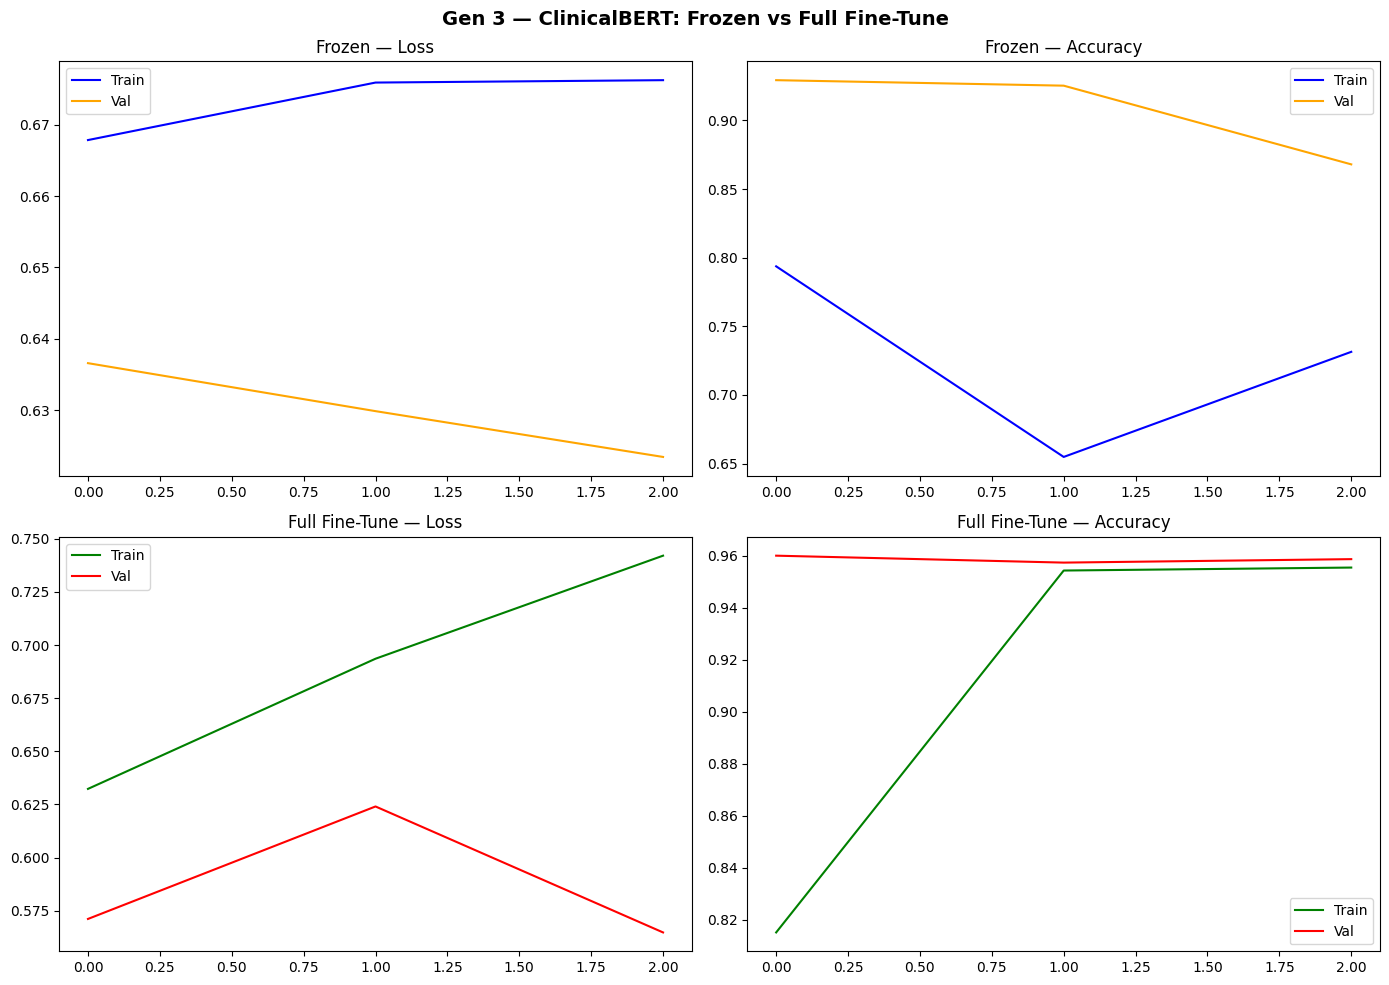

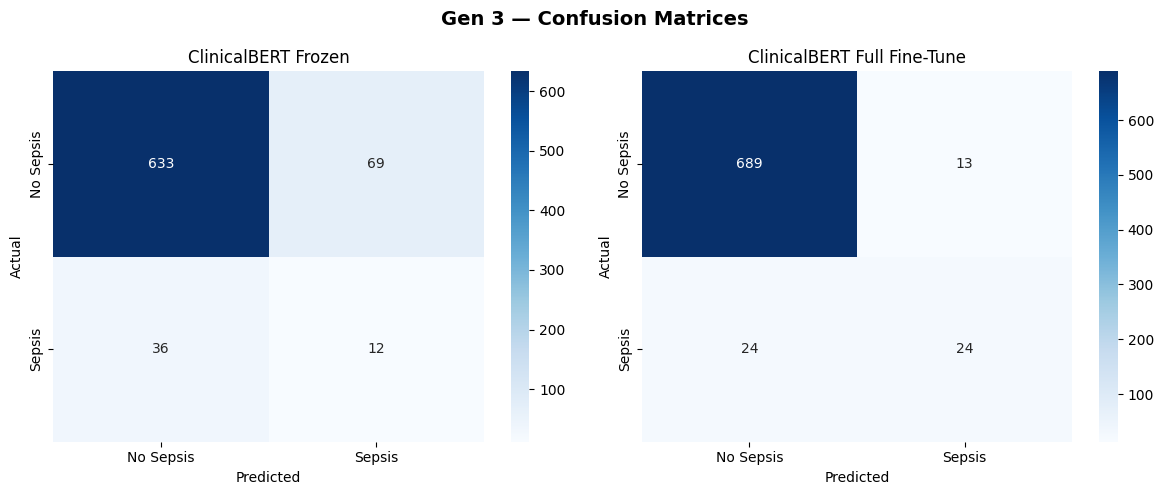

Gen 3 Results:
                      Model  Accuracy  Precision  Recall     F1  Train Time (s)
        ClinicalBERT Frozen    0.8600     0.1481    0.25 0.1860          1325.7
ClinicalBERT Full Fine-Tune    0.9507     0.6486    0.50 0.5647          6238.7


In [37]:
# ── Evaluate Gen 3 models ─────────────────────────────────────
res_frozen = evaluate_bert(model_frozen, test_loader, 'ClinicalBERT Frozen')
res_ft     = evaluate_bert(model_ft,     test_loader, 'ClinicalBERT Full Fine-Tune')

# Training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gen 3 — ClinicalBERT: Frozen vs Full Fine-Tune', fontsize=14, fontweight='bold')
for row, (hist, name, c1, c2) in enumerate([
    (hist_frozen, 'Frozen', 'blue', 'orange'),
    (hist_ft, 'Full Fine-Tune', 'green', 'red')
]):
    axes[row,0].plot(hist['train_loss'], color=c1, label='Train')
    axes[row,0].plot(hist['val_loss'],   color=c2, label='Val')
    axes[row,0].set_title(f'{name} — Loss'); axes[row,0].legend()
    axes[row,1].plot(hist['train_acc'], color=c1, label='Train')
    axes[row,1].plot(hist['val_acc'],   color=c2, label='Val')
    axes[row,1].set_title(f'{name} — Accuracy'); axes[row,1].legend()
plt.tight_layout()
plt.savefig('gen3_training_history.png', dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gen 3 — Confusion Matrices', fontsize=14, fontweight='bold')
for ax, res, title in zip(axes, [res_frozen, res_ft],
                           ['ClinicalBERT Frozen', 'ClinicalBERT Full Fine-Tune']):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Sepsis','Sepsis'], yticklabels=['No Sepsis','Sepsis'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('gen3_confusion_matrices.png', dpi=150)
plt.show()

gen3_comparison = pd.DataFrame([
    {'Model': 'ClinicalBERT Frozen', 'Accuracy': res_frozen['Accuracy'],
     'Precision': res_frozen['Precision'], 'Recall': res_frozen['Recall'],
     'F1': res_frozen['F1'], 'Train Time (s)': round(frozen_time,1)},
    {'Model': 'ClinicalBERT Full Fine-Tune', 'Accuracy': res_ft['Accuracy'],
     'Precision': res_ft['Precision'], 'Recall': res_ft['Recall'],
     'F1': res_ft['F1'], 'Train Time (s)': round(ft_time,1)}
])
print('Gen 3 Results:')
print(gen3_comparison.to_string(index=False))
gen3_comparison.to_csv('gen3_results.csv', index=False)

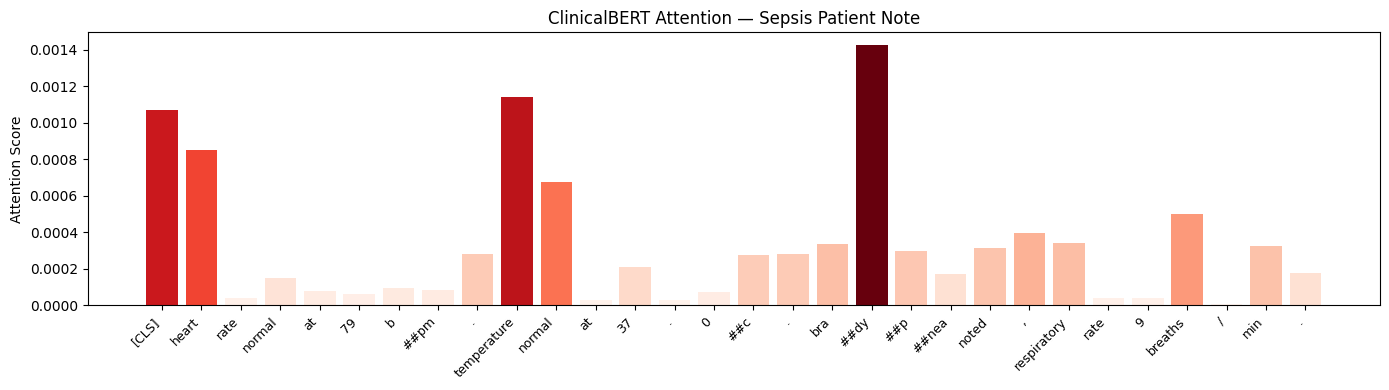

In [38]:
# ── Attention Heatmap ─────────────────────────────────────────
# Visualizes which words ClinicalBERT focuses on for sepsis prediction
# CLS token attention shows word-level importance across the note
# Higher bar = model found that word more relevant for classification
def plot_attention(model, tokenizer, text, title='Attention Heatmap'):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                       max_length=64, padding='max_length').to(device)
    with torch.no_grad():
        out = model(**inputs, output_attentions=True)
    attn = out.attentions[-1][0, 0].cpu().numpy()[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())
    mask = inputs['attention_mask'][0].cpu().numpy()
    tok_f = [t for t,m in zip(tokens,mask) if m==1][:30]
    att_f = [a for a,m in zip(attn,mask) if m==1][:30]
    plt.figure(figsize=(14, 4))
    plt.bar(range(len(tok_f)), att_f,
            color=plt.cm.Reds(np.array(att_f)/max(att_f)))
    plt.xticks(range(len(tok_f)), tok_f, rotation=45, ha='right', fontsize=9)
    plt.ylabel('Attention Score')
    plt.title(title)
    plt.tight_layout()
    plt.savefig('gen3_attention_heatmap.png', dpi=150)
    plt.show()

sepsis_note = df3_sample[df3_sample['SepsisLabel']==1].iloc[0]['clinical_note']
plot_attention(model_ft, tokenizer, sepsis_note,
               title='ClinicalBERT Attention — Sepsis Patient Note')

---
# PART 5 — FINAL COMPARISON: ALL 6 MODELS

FINAL COMPARISON TABLE — ALL 6 MODELS
                      Model  Accuracy  Precision  Recall     F1  Train Time (s)
                  DNN + SGD    0.8169     0.0553  0.5712 0.1009            59.2
                 DNN + Adam    0.7816     0.0509  0.6311 0.0942           314.9
                       LSTM    0.8973     0.3820  0.6616 0.4844            86.4
         Bidirectional LSTM    0.8858     0.3595  0.7256 0.4808           185.7
                        GRU    0.8989     0.3896  0.6829 0.4961            21.9
        ClinicalBERT Frozen    0.8600     0.1481  0.2500 0.1860          1325.7
ClinicalBERT Full Fine-Tune    0.9507     0.6486  0.5000 0.5647          6238.7

>> Best Recall model = recommended for deployment

Saved: final_all_models_comparison.csv


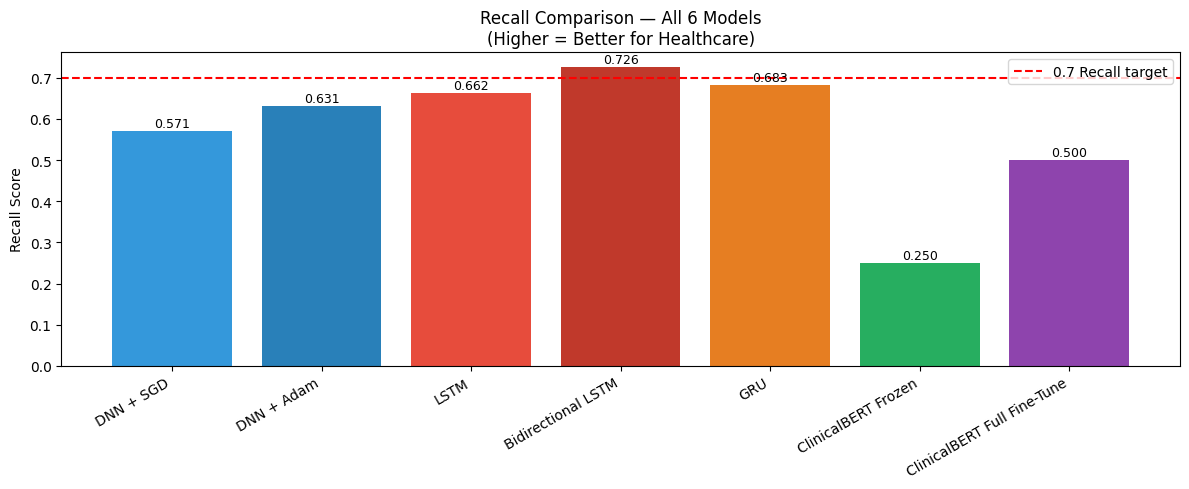

In [39]:
# ── Final Comparison Table — All 6 Models ─────────────────────
# Recall is the most important metric in healthcare
# Missing a sepsis case (false negative) can be fatal
# A false alarm (false positive) is less dangerous — just extra monitoring
all_results = pd.concat([
    gen1_comparison,
    gen2_comparison,
    gen3_comparison
], ignore_index=True)

print('=' * 70)
print('FINAL COMPARISON TABLE — ALL 6 MODELS')
print('=' * 70)
print(all_results.to_string(index=False))
print('\n>> Best Recall model = recommended for deployment')

all_results.to_csv('final_all_models_comparison.csv', index=False)
print('\nSaved: final_all_models_comparison.csv')

# Plot Recall comparison
plt.figure(figsize=(12, 5))
colors = ['#3498db','#2980b9','#e74c3c','#c0392b','#e67e22','#27ae60','#8e44ad']
bars = plt.bar(all_results['Model'], all_results['Recall'], color=colors[:len(all_results)])
plt.axhline(y=0.7, color='red', linestyle='--', label='0.7 Recall target')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Recall Score')
plt.title('Recall Comparison — All 6 Models\n(Higher = Better for Healthcare)')
plt.legend()
for bar, val in zip(bars, all_results['Recall']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('final_recall_comparison.png', dpi=150)
plt.show()